# Overview and main features

**1. Import packages and setup environment (CPU/GPU/TPU):**
* Automatic recognition of TPU environment and installation of necessary packages (as for TPU accelerator currently no dependency installation code is available).

**2. Load and preprocess data into datasets:**
* Read csv files and merge them into a unified single trainval dataframe.
* Preprocess audio and labels including data augmentation applying shifting over time axis.
* Split data into train and validation sets. Stratification on primary label (*STRAT == True*) and/or grouping on file name (*GROUP == True*) can be configured.

**3. Explore data:**
* Check data dimensions.
* Play random sample from dataset and show waveform/spectrogram.
* Compare probabilty distribution of labels between train and validation sets.

**4. Build and compile neural network:**
* Build audio classifier consisting following modules:
    *  Audio transformator module converting waveform into mel-spectrogram (optional into mfcc/lfcc) and 1-channel into 3-channel representation either by projection (*PROJ_3CH == True*) or concatenation.
    * EfficientNet backbone for feature extraction. Parameters can be initialized with pretrained values (*PRETRAINED_BACKBONE == True*).
* Explore model architecture.

**5. Training:**
* Custom specific focal loss function for strongly imbalanced multi label classification.
* Custom specific training loop using knowledge distillation from pretrained Perch 2.0 model.

**6. Evaluation:**
* Show training curves (metric/loss/learning rate).
* Predict labels for a random sample from the validation set.

**7. Submission:**
* Predict labels of test audio samples and create submission.csv file.

# 1. Import packages and setup environment (CPU/GPU/TPU)

In [1]:
## Detect hardware (CPU/GPU/TPU) and setup environment

import torch
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.parallel_loader as pl
    TPU_AVAILABLE = True
except ImportError:
    TPU_AVAILABLE = False
    
if TPU_AVAILABLE:
    DEVICE = xm.xla_device()
    !pip install soundfile -q
    !pip install torchinfo -q
    CPU_ONLY = False
else:
    if torch.cuda.is_available():
        #!pip install tensorflow[and-cuda]~=2.20.0 -q
        DEVICE = torch.device("cuda")
        CPU_ONLY = False
    else:
        DEVICE = torch.device("cpu")
        CPU_ONLY = True

In [2]:
## Import packages

# General purpose modules
import os
import sys
import random
import math
import ast
import warnings
import gc
from pathlib import Path
from contextlib import nullcontext

# Audio processing modules
import soundfile as sf

# Data handling and visualization modules
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from IPython.display import Audio, display, HTML

# Skikit-learn preprocessing modules
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedGroupKFold

# PyTorch modules
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR, ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import torchvision.models as models
import torchvision.transforms as TV
from torchinfo import summary
print('PyTorch version: '+ torch.__version__)

# Tensorflow modules
# import tensorflow_hub as hub
# import tensorflow as tf
# print('Tensorflow version: '+ tf.__version__)

PyTorch version: 2.6.0+cu124


# 2. Load and preprocess data into datasets

In [3]:
## Configuration of audio preprocessing

SUBMISSIONING = True
SAMPLE_RATE = 32000                         # Target sample rate
N_MELS = 128                                # Number of Mel bands
N_FFT = 1024                                # FFT window size
HOP_LENGTH = 320                            # Hop length for Mel Spectrogram
WIN_LENGTH = 640                            # Windows length for Mel Spectrogram
SAMPLE_DURATION = 5                         # Duration of audio samples to process (pad/truncate)
MAX_AUDIO_LEN = 10                          # Max duration of audio to consider for preprocessing
N_SAMPLES = SAMPLE_RATE * SAMPLE_DURATION   # Number of samples of preprocessed audio files
F_MIN       = 60                            # Minimum frequency
F_MAX       = 16000                         # Maximum frequency
BATCH_SIZE = 64
IMAGENET_MEAN = 0.449
IMAGENET_STD = 0.226

In [4]:
## Helping function to slice audio files into 5 sec samples

def make_audio_slices_list(audio_full_paths, max_audio_len=MAX_AUDIO_LEN):
    audio_slices = []
    for audio_full_path in tqdm(audio_full_paths, mininterval=30):
        # Set total frame length of audio slices
        try:
            info = sf.info(audio_full_path)
            total = min(info.frames, SAMPLE_RATE * max_audio_len)
        except Exception:
            print('Error during reading of ' + audio_full_path)
            continue
            
        # List all possible slices and return them in a dataframe
        stem = audio_full_path.split('/')[-1].split('.')[0]
        end_sec = SAMPLE_DURATION
        start = 0
        while start + N_SAMPLES <= total:
            audio_slices.append((audio_full_path, int(start/SAMPLE_RATE), end_sec, f'{stem}_{end_sec}'))
            start += N_SAMPLES
            end_sec += SAMPLE_DURATION
    return pd.DataFrame(audio_slices, columns=['full_path', 'start_sec', 'stop_sec', 'row_id'])

In [5]:
## Read csv files and merge them into a single dataframe

if (not SUBMISSIONING) & (MAX_AUDIO_LEN != 10) & (MAX_AUDIO_LEN != 3000):
    trainval = pd.read_csv('/kaggle/input/competitions/birdclef-2026/train.csv')
    trainval_extra = pd.read_csv('/kaggle/input/competitions/birdclef-2026/train_soundscapes_labels.csv')
    
    # Merge and standardize label informations from different columns of data source tables (all labels in a single string seperated by ;)
    trainval['all_labels'] = trainval.apply(lambda row: ';'.join([row['primary_label']] + ast.literal_eval(row['secondary_labels'])), axis=1)
    trainval_extra = trainval_extra.drop_duplicates().reset_index(drop=True).rename(columns={'primary_label': 'all_labels'})
    trainval_extra['primary_label'] = trainval_extra['all_labels'].str.split(';').str[0]
    trainval_extra['secondary_labels'] = trainval_extra['all_labels'].str.split(';').str[1:]
    
    # Include full paths in the data source tables
    trainval['full_path'] = '/kaggle/input/competitions/birdclef-2026/train_audio/' + trainval['filename']
    trainval_extra['full_path'] = '/kaggle/input/competitions/birdclef-2026/train_soundscapes/' + trainval_extra['filename']
    
    # Create a list of 5 sec slices of audio files and merge information into trainval
    audio_full_paths = trainval['full_path'].unique().tolist()
    slices_df = make_audio_slices_list(audio_full_paths)
    trainval = pd.merge(trainval, slices_df, on='full_path', how='right')
    
    # Standardize start and end time columns by converting them to seconds in integer
    trainval_extra['start_sec'] = pd.to_timedelta(trainval_extra['start']).dt.total_seconds().astype(int)
    trainval_extra['stop_sec'] = pd.to_timedelta(trainval_extra['end']).dt.total_seconds().astype(int)
    
    # Merge the two datasets into one single dataframe
    trainval = pd.concat([trainval, trainval_extra], axis=0)
elif MAX_AUDIO_LEN == 3000:
    trainval = pd.read_csv('/kaggle/input/datasets/kospintr/birdclef-perch-emb/trainval_full.csv')
else:
    trainval = pd.read_csv('/kaggle/input/datasets/kospintr/birdclef-perch-emb/trainval_len10.csv')
taxonomy = pd.read_csv('/kaggle/input/competitions/birdclef-2026/taxonomy.csv')

/tmp/ipykernel_12/951737344.py:31: DtypeWarning: Columns (20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  trainval = pd.read_csv('/kaggle/input/datasets/kospintr/birdclef-perch-emb/trainval_len10.csv')


In [6]:
## Fitting multi label binarizer

all_unique_labels = trainval['all_labels'].str.split(';').explode().unique()
mlb = MultiLabelBinarizer()
mlb.fit([all_unique_labels])
print(f"\nTotal unique labels: {len(all_unique_labels)}")
print(f"Label classes: {mlb.classes_}")


Total unique labels: 234
Label classes: ['1161364' '116570' '1176823' '1491113' '1595929' '209233' '22930' '22956'
 '22961' '22967' '22973' '22983' '22985' '23150' '23154' '23158' '23176'
 '23724' '24279' '24285' '24287' '24321' '244024' '25073' '25092' '25214'
 '326272' '41970' '43435' '47144' '47158son01' '47158son02' '47158son03'
 '47158son04' '47158son05' '47158son06' '47158son07' '47158son08'
 '47158son09' '47158son10' '47158son11' '47158son12' '47158son13'
 '47158son14' '47158son15' '47158son16' '47158son17' '47158son18'
 '47158son19' '47158son20' '47158son21' '47158son22' '47158son23'
 '47158son24' '47158son25' '476521' '516975' '517063' '555123' '555145'
 '555146' '64898' '65377' '65380' '66971' '67107' '67252' '70711' '738183'
 '74113' '74580' '760266' 'ashgre1' 'astcra1' 'bafcur1' 'baffal1' 'banana'
 'barant1' 'batbel1' 'baymac' 'bbwduc' 'bcwfin2' 'bkcdon' 'bkhpar'
 'blchaw1' 'blheag1' 'blttit1' 'bncfly' 'bobfly1' 'brcmar1' 'brnowl'
 'bucmot4' 'bucpar' 'bufpar' 'bunibi1' 'bu

In [7]:
## Custom Dataset including caching into memory and disk

class AnimalSoundDataset(Dataset):
    def __init__(self, dataframe, perch_embeddings=None, mlb=mlb, cache_file_name=None,
                 augmentation=False, submissioning=False):
        self.dataframe = dataframe
        self.mel_trans = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                                          n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX, power=2.0)
        self.db_trans = T.AmplitudeToDB(top_db=100)
        self.perch_embeddings = perch_embeddings
        self.mlb = mlb
        self.sample_rate = SAMPLE_RATE
        self.max_audio_samples = N_SAMPLES
        self.augmentation = augmentation
        self.max_shift = 100
        self.submissioning = submissioning

        # Cache related
        self.cache_file_name = cache_file_name
        if not os.path.isfile(self.cache_file_name):
            torch.save({}, self.cache_file_name)
        self.cache = {}
        self.mmap_cache = torch.load(self.cache_file_name, mmap=True, weights_only=True)
        
    def __len__(self):
        return len(self.dataframe)

    def _load_audio_slice_at(self, path, start_sample):
        stereo_waveform, sr = sf.read(path, start=start_sample, stop=start_sample + self.max_audio_samples, dtype='float32', always_2d=True)
        waveform = stereo_waveform.mean(axis=1)
        waveform = torch.from_numpy(waveform).unsqueeze(0)
        return waveform, sr

    def _process_audio(self, audio_path_full, start_samples):
        # Cut 5 sec audio sample with defined starting time from given audio file
        waveform, sr = self._load_audio_slice_at(audio_path_full, start_samples)

        # Resample waveform if necessary
        if sr != self.sample_rate:
            resampler = T.Resample(orig_freq=sr, new_freq=self.sample_rate)
            waveform = resampler(waveform)

        # Padding or truncating sample if necessary
        current_n_samples = waveform.shape[1]
        if current_n_samples < self.max_audio_samples:
            padding_needed = self.max_audio_samples - current_n_samples
            waveform = F.pad(waveform, (0, padding_needed))
        elif current_n_samples > self.max_audio_samples:
            waveform = waveform[:, :self.max_audio_samples]
        return waveform

    def _mel_spect(self, waveform):
        mel_spect = self.mel_trans(waveform)
        mel_spect_db = self.db_trans(mel_spect)/20*0.1
        return mel_spect_db

    def _augmentation(self, x):
        shift = random.randint(-self.max_shift, self.max_shift)
        return torch.roll(x, shifts=shift, dims=-1)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        audio_path_full = row['full_path']
        start_samples = row['start_sec'] * self.sample_rate
        labels = row['all_labels'].split(';')
        row_id = row['row_id']

        # Preprocess audio file (Try to load from in-memory cache first then try to load from disk cache)
        if idx in self.cache:
            mel_spect_db = self.cache[idx]
            waveform = torch.zeros(1, 1) # Dummy value
        elif idx in self.mmap_cache:
            mel_spect_db = self.mmap_cache[idx]
            waveform = torch.zeros(1, 1) # Dummy value
        else:
            waveform = self._process_audio(audio_path_full, start_samples)
            mel_spect_db = self._mel_spect(waveform)
            self.cache[idx] = mel_spect_db
            if (len(self.cache) >= 490330):
                torch.save(self.cache, self.cache_file_name)
                self.mmap_cache = torch.load(self.cache_file_name, mmap=True, weights_only=True)
                self.cache = {}
                gc.collect()

        # Data augmentation
        if self.augmentation:
            mel_spect_db = self._augmentation(mel_spect_db)

        # Label encoding (Multi onehot coding)
        one_hot_labels = torch.tensor(self.mlb.transform([labels]).squeeze(0), dtype=torch.float32)

        # Soft labels from perch model
        if not self.submissioning:
            perch_embedding = self.perch_embeddings[idx, :]

        return (mel_spect_db, one_hot_labels, perch_embedding, waveform) if not self.submissioning else (mel_spect_db, one_hot_labels, row_id)

In [8]:
## Extract Perch embeddings

if (not SUBMISSIONING) & (MAX_AUDIO_LEN != 10) & (MAX_AUDIO_LEN != 3000):
    EMB_MODEL = '/kaggle/input/models/google/bird-vocalization-classifier/tensorflow2/perch_v2/2'
    trainval_dataset = AnimalSoundDataset(trainval, perch_embeddings=torch.zeros(len(trainval), 1536))
    trainval_loader = DataLoader(trainval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True,
                                 prefetch_factor=2, drop_last=False)
    embedding_model = hub.load(EMB_MODEL).signatures['serving_default']
    trainval_perch_emb = []
    for _, _, _, waveforms in trainval_loader:
        perch_model_outputs = embedding_model(inputs=tf.convert_to_tensor(waveforms[:,0,:], dtype=tf.float32))
        trainval_perch_emb.append(torch.from_numpy(perch_model_outputs['embedding'].numpy()))
    trainval_perch_emb = torch.concat(trainval_perch_emb)
elif MAX_AUDIO_LEN == 3000:
    trainval_perch_emb = torch.load(
        '/kaggle/input/datasets/kospintr/birdclef-perch-emb/trainval_perch_full.pt', map_location='cpu')
else:
    trainval_perch_emb = torch.load(
        '/kaggle/input/datasets/kospintr/birdclef-perch-emb/trainval_perch_len10.pt', map_location='cpu')

In [9]:
## Split train/validation data

STRAT = True
GROUP = True
N_SPLITS = 5

splitter = (StratifiedGroupKFold if STRAT else GroupKFold) if GROUP else (StratifiedKFold if STRAT else KFold)

skf = splitter(n_splits=N_SPLITS, shuffle=True, random_state=42).split(trainval, trainval['primary_label'], trainval['filename'])

# Split train/validation data
for i, (train_idx, val_idx) in enumerate(skf):
    train, train_perch_emb = trainval.iloc[train_idx], trainval_perch_emb[train_idx, :]
    val, val_perch_emb = trainval.iloc[val_idx], trainval_perch_emb[val_idx, :]
    break

# Verify sample sizes
print(f"Total samples:      {int(len(trainval))}")
print(f"Dev train samples:  {int(len(train))} ({len(train)/len(trainval):.2%})")
print(f"Dev valid samples:  {int(len(val))} ({len(val)/len(trainval):.2%})")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:909: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Total samples:      61255
Dev train samples:  49033 (80.05%)
Dev valid samples:  12222 (19.95%)


In [10]:
## Create dataset and split into training and validation sets

train_dataset = AnimalSoundDataset(train, train_perch_emb, cache_file_name='mmap_cache.pt', augmentation=True)
val_dataset = AnimalSoundDataset(val, val_perch_emb, cache_file_name='mmap_cache_val.pt')

if TPU_AVAILABLE:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)

In [11]:
## Cache dataset

if not SUBMISSIONING:
    for _, _, _, _ in tqdm(train_dataset, mininterval=30):
        pass
    for _, _, _, _ in tqdm(val_dataset, mininterval=30):
        pass
    
    print(f'Memory cache counter: {len(train_dataset.cache)}')
    print(f'Disk cache counter: {len(train_dataset.mmap_cache)}')
    print(f'Memory cache counter of val_dataset: {len(val_dataset.cache)}')
    print(f'Disk cache counter of val_dataset: {len(val_dataset.mmap_cache)}')

# 3. Explore data

In [12]:
## Check a sample from the dataloader

for mel_spect_dbs, one_hot_labels, perch_emb, _ in train_loader:
    print(f"Mel-spectrogram batch shape: {mel_spect_dbs.shape}")        # Should be [batch_size, 1, n_mels, time_frames]
    print(f"One-hot-coded labels batch shape: {one_hot_labels.shape}")  # Should be [batch_size, num_labels]
    print(f"Perch embedding batch shape: {perch_emb.shape}")            # Should be [batch_size, 1536]
    print(f"Expected size of whole dataset: {mel_spect_dbs.element_size()*mel_spect_dbs.numel()*len(trainval)/BATCH_SIZE/1024**3} GByte")
    break

Mel-spectrogram batch shape: torch.Size([64, 1, 128, 501])
One-hot-coded labels batch shape: torch.Size([64, 234])
Perch embedding batch shape: torch.Size([64, 1536])
Expected size of whole dataset: 14.633538722991943 GByte


In [13]:
## Configure audio transformation function

mel_trans = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                             n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX, power=2.0)
mfcc_trans = T.MFCC(sample_rate=SAMPLE_RATE, n_mfcc=N_MELS, melkwargs={"n_fft": N_FFT, "n_mels": N_MELS, "hop_length": HOP_LENGTH})
lfcc_trans = T.LFCC(sample_rate=SAMPLE_RATE, n_lfcc=N_MELS, speckwargs={"n_fft": N_FFT, "hop_length": HOP_LENGTH})
db_trans = T.AmplitudeToDB(top_db=100)

def audio_transformations(waveform):
    mel_spect_db = db_trans(mel_trans(waveform))
    mfcc_db = db_trans(mfcc_trans(waveform))
    lfcc_db = db_trans(lfcc_trans(waveform))
    return mel_spect_db, mfcc_db, lfcc_db

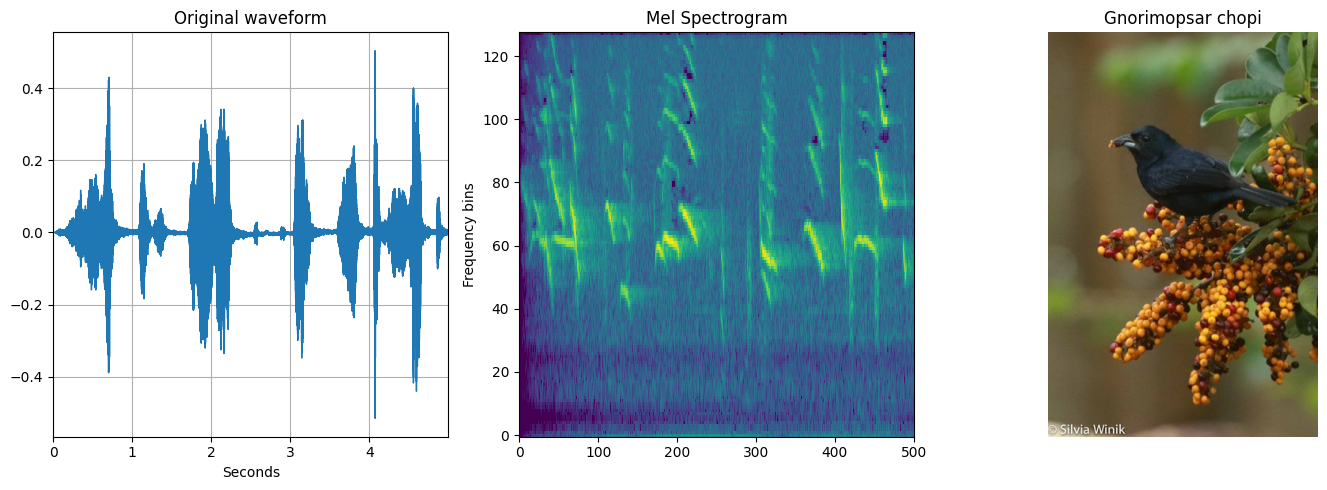

In [14]:
## Play random sample from validation dataset and show waveform/spectrogram 

# Take a random sample of dataset
mel_spect_db, one_hot_labels, _, waveform = val_dataset[random.randint(0, len(val))]
common_name = taxonomy['common_name'][taxonomy['primary_label'] == mlb.inverse_transform(one_hot_labels.unsqueeze(0))[0][0]].values[0]
scientific_name = taxonomy['scientific_name'][taxonomy['primary_label'] == mlb.inverse_transform(one_hot_labels.unsqueeze(0))[0][0]].values[0]
num_channels, num_frames = waveform.shape
time_axis = torch.arange(0, num_frames) / SAMPLE_RATE

# Show waveform and spectrogram of sample
display(HTML(f"<h3>{common_name} ({scientific_name})</h3>"))
display(Audio(waveform.numpy(), rate=SAMPLE_RATE))
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

axs[0].plot(time_axis, waveform[0], linewidth=1)
axs[0].set_title('Original waveform')
axs[0].set_xlim([0, time_axis[-1]])
axs[0].set_xlabel('Seconds')
axs[0].grid(True)
axs[1].imshow(mel_spect_db[0], origin="lower", aspect="auto", interpolation="nearest")
axs[1].set_title('Mel Spectrogram')
axs[1].set_ylabel('Frequency bins')
try:
    folder = scientific_name.lower().strip().replace(" ", "_")
    file_name = os.listdir('/kaggle/input/datasets/kospintr/birdclef-animal-images/animal_samples/' + folder)[0]
    image_path = '/kaggle/input/datasets/kospintr/birdclef-animal-images/animal_samples/'+folder+'/'+file_name
    img = Image.open(image_path)
    axs[2].imshow(img)
    axs[2].set_title(f'{scientific_name}')
    axs[2].axis('off')
except:
    axs[2].text(0.5, 0.5, "No image available", fontsize=16, ha='center', va='center')
    axs[2].axis('off')

fig.tight_layout()

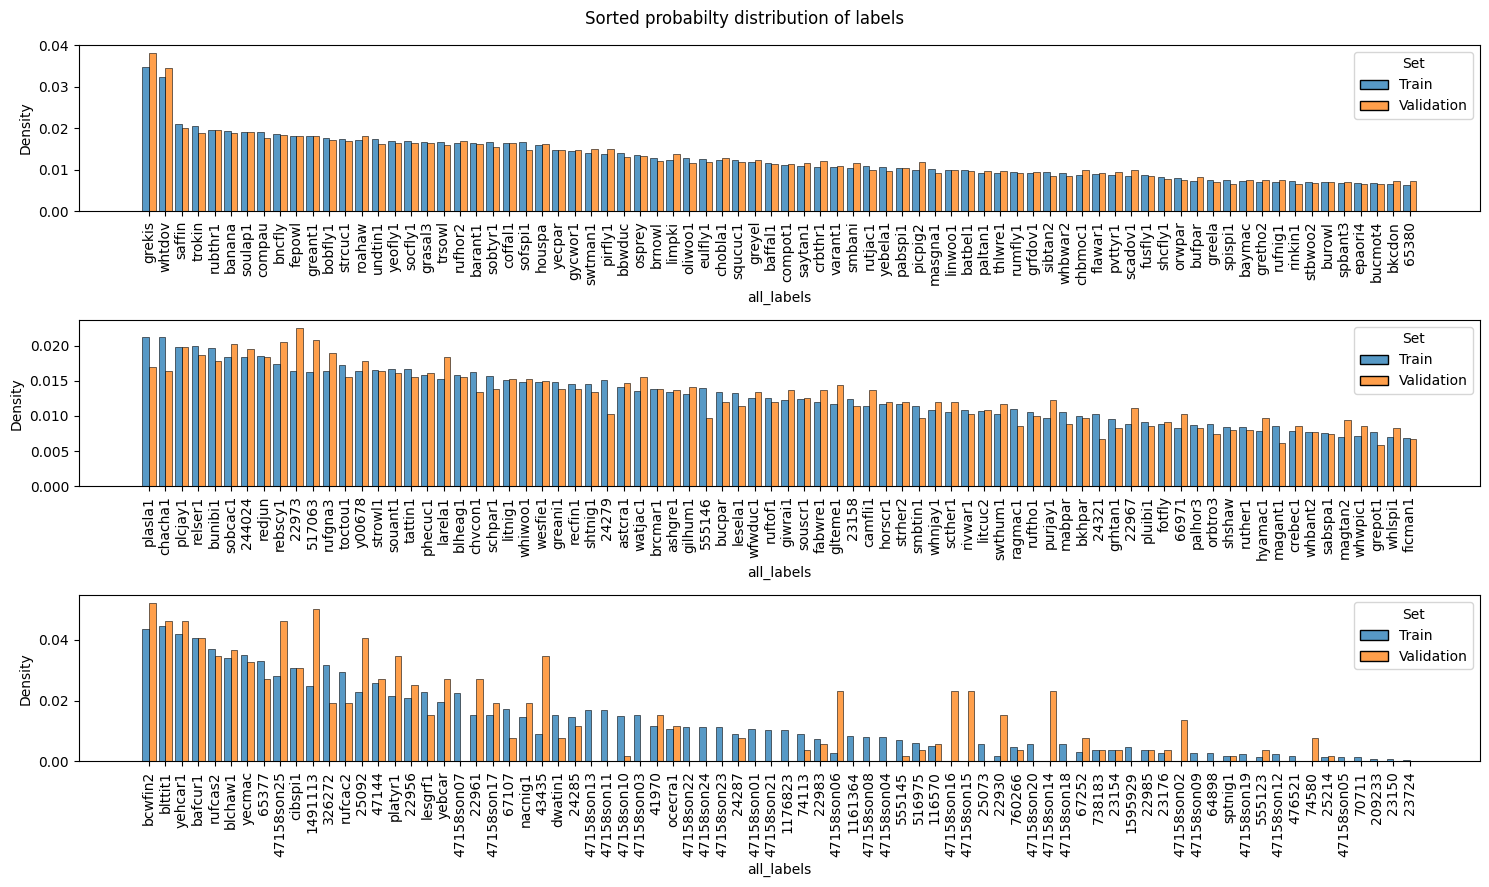

In [15]:
## Compare probabilty distribution of labels between train and validation sets

# Create a dataframe with assigned sources (train/validation)
df_plot = pd.concat([train['all_labels'].str.split(';').explode().to_frame().assign(Set='Train'),
                     val['all_labels'].str.split(';').explode().to_frame().assign(Set='Validation')])
    
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn") # Suppress the specific FutureWarning

# Plot probabilty distribution of features
plot_cols = 'all_labels'
num_facets = 3
num_cats_per_plot = math.ceil(len(df_plot['all_labels'].unique())/num_facets)
n_cols = 1
n_rows = math.ceil(num_facets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()
ordered_cats = df_plot[plot_cols].value_counts().index.tolist()
for i in range(num_facets):
    sub_cats = ordered_cats[i*num_cats_per_plot:(i+1)*num_cats_per_plot]
    df_plot_fil = df_plot[df_plot[plot_cols].isin(sub_cats)]
    ordered_sub_cats = df_plot_fil[plot_cols].value_counts().index.tolist()
    df_plot_fil.loc[:, ['ordered']] = pd.Categorical(df_plot_fil[plot_cols], categories=ordered_sub_cats, ordered=True)
    df_plot_fil = df_plot_fil.sort_values(by='ordered')
    
    sns.histplot(data=df_plot_fil, x=plot_cols, ax=axes[i], hue='Set', log_scale=False,
                     stat='density', discrete=True, multiple="dodge", common_norm=False, shrink=.8)

_ = [label.set_rotation(90) for ax in axes.flat for label in ax.get_xticklabels()]
fig.suptitle('Sorted probabilty distribution of labels')
plt.tight_layout()
plt.show()

# 4. Build and compile neural network

In [16]:
## Build audio classifier model using EfficientNet backbone

PRETRAINED_BACKBONE = True # Use pretrained backbone
PROJ_3CH = False # Use projection instead concat to transform 1-channel mel-spectrogram into 3-channel presentation

# Audio transformator module converting waveform into mel-spectrogram (optional into mfcc/lfcc)
class AudioTransformator(nn.Module):
    def __init__(self):
        super(AudioTransformator, self).__init__()
        # self.mel_trans = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
        #                                   n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX, power=2.0)
        # self.mfcc_trans = T.MFCC(sample_rate=SAMPLE_RATE, n_mfcc=N_MELS, melkwargs={"n_fft": N_FFT, "n_mels": N_MELS, "hop_length": HOP_LENGTH})
        # self.lfcc_trans = T.LFCC(sample_rate=SAMPLE_RATE, n_lfcc=N_MELS, speckwargs={"n_fft": N_FFT, "hop_length": HOP_LENGTH})
        # self.db_trans = T.AmplitudeToDB(top_db=100)
        self.proj = nn.Conv2d(1, 3, kernel_size=1)

    def forward(self, mel_spect_db):
        # Convert 1-channel mel-spectrogram into 3-channel
        if PROJ_3CH:
            transforms = self.proj(mel_spect_db)
        else:
            transforms = torch.concat([mel_spect_db, mel_spect_db, mel_spect_db], axis=1)
        return transforms

# Audio classifier model
class AudioClassifier(nn.Module):
    def __init__(self, num_classes, in_channels=1, pretrained=True):
        super(AudioClassifier, self).__init__()

        self.audio_transform = AudioTransformator()

        # Load backbone model
        backbone = models.efficientnet_b3(weights=None if (SUBMISSIONING or (not PRETRAINED_BACKBONE)) else 'IMAGENET1K_V1')
        #backbone = models.resnet18(weights=None if (SUBMISSIONING or (not PRETRAINED_BACKBONE)) else 'IMAGENET1K_V1')
        # Remove classification head
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        
        # Linear transformation of model embeddings to perch dimensions
        self.embedding_transform = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(1536, 1536) #1280
        )
        
        # New classification head
        self.classifier = nn.Sequential(
            #nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1536, num_classes),
        )
    def forward(self, x):
        # Transform waveform into mel spectrogram/mfcc/lfcc, convert them to dB scale and normalize 
        transforms = self.audio_transform(x)
        
        # Extract spatial features and flatten spatial dims into time steps
        feats = self.feature_extractor(transforms)
        
        # Convert backbone embeddings into perch embedding dimensions
        emb = self.embedding_transform(feats)
        
        # Classify
        out = self.classifier(emb)
        return out, emb

model = AudioClassifier(num_classes=len(all_unique_labels)).to(DEVICE)

In [17]:
# ## Freeze BatchNorm stats to avoid NaN issue on TPU
# def freeze_bn(m):
#     if isinstance(m, nn.BatchNorm2d):
#         m.eval()
#         m.weight.requires_grad_(False)  # freeze gamma
#         m.bias.requires_grad_(False)    # freeze beta

# if TPU_AVAILABLE:
#     model.apply(freeze_bn)

In [18]:
## Explore model architecture

summary(AudioClassifier(num_classes=len(all_unique_labels)).to(DEVICE), input_size=mel_spect_dbs.shape)

Layer (type:depth-idx)                                       Output Shape              Param #
AudioClassifier                                              [64, 234]                 --
├─AudioTransformator: 1-1                                    [64, 3, 128, 501]         6
├─Sequential: 1-2                                            [64, 1536, 1, 1]          --
│    └─Sequential: 2-1                                       [64, 1536, 4, 16]         --
│    │    └─Conv2dNormActivation: 3-1                        [64, 40, 64, 251]         1,160
│    │    └─Sequential: 3-2                                  [64, 24, 64, 251]         3,504
│    │    └─Sequential: 3-3                                  [64, 32, 32, 126]         48,118
│    │    └─Sequential: 3-4                                  [64, 48, 16, 63]          110,912
│    │    └─Sequential: 3-5                                  [64, 96, 8, 32]           638,700
│    │    └─Sequential: 3-6                                  [64, 136, 8, 32

# 5. Training

In [19]:
## Compute alpha_pos and pos_weight for each class

labels_ls = []
for row in tqdm(trainval['all_labels'].str.split(';')):
    one_hot_labels = torch.tensor(mlb.transform([row]).squeeze(0), dtype=torch.float32)
    labels_ls.append(one_hot_labels)
labels_tensor = torch.stack(labels_ls, axis=0)

@torch.no_grad()
def alpha_from_counts(labels_tensor, clamp_min=1e-2, clamp_max=1-1e-6):
    """
    pos_counts: Tensor[C] number of positives for each label
    total_count: total number of samples N
    pos_rate: Tensor[C] containing prevalence p_j in (0,1)
    returns: Tensor[C] alpha for positive class
    """
    total_count = len(labels_tensor)
    pos_counts = labels_tensor.sum(dim=0)
    pos_rate = pos_counts / total_count
    p = pos_rate.clamp(clamp_min, clamp_max)
    pos_weight = (1.0 - p) / p
    alpha_pos = pos_weight / (1.0 + pos_weight)  # = 1 - p, but numerically stable in this form   
    return alpha_pos.to(DEVICE), pos_weight.to(DEVICE)

alpha_pos, pos_weight = alpha_from_counts(labels_tensor)

100%|██████████| 61255/61255 [00:05<00:00, 11333.15it/s]


In [20]:
## Custom specific focal loss function for strongly imbalanced multi label classification

class MultiLabelFocalLoss(nn.Module):
    """ Multi-label focal loss (sigmoid + BCEWithLogits) with optional per-class alpha for multi-label classification.
        Inputs:
            logits: Tensor[B, C] (raw, unnormalized scores)
            targets: Tensor[B, C] in {0,1} (or float in [0,1] if you use soft labels)
        Parameters:
            gamma (float): Focusing parameter to reduce loss for easy examples. (typical 1-2)
            alpha (Tensor[C]): Per-class weighting factor for positive examples (0 < alpha <= 1).
            reduction (str): 'mean' | 'sum' | 'none'
            eps (float): numerical stability for clamp"""
    
    def __init__(self, gamma=1.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = float(gamma)
        self.reduction = reduction

        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor(float(alpha))
        else:
            self.alpha = torch.as_tensor(alpha, dtype=torch.float32)

    def forward(self, logits, targets):
        # BCE with logits (shape [B, C])
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        # Probabilities for the true class
        p_true = torch.exp(-bce_loss)

        # alpha_t = alpha if y==1 else (1-alpha)
        if self.alpha is None:
            alpha_t = 1.0
        else:
            alpha = self.alpha.to(device=logits.device, dtype=logits.dtype)
            if alpha.ndim == 0:
                # scalar alpha
                alpha_t = alpha * targets + (1.0 - alpha) * (1.0 - targets)
            else:
                # per-class alpha: [C] -> broadcast to [B, C]
                alpha = alpha.view(1, -1)
                alpha_t = alpha * targets + (1.0 - alpha) * (1.0 - targets)

        focal_weight = (1.0 - p_true).pow(self.gamma)
        focal_loss = alpha_t * focal_weight * bce_loss  # shape [B, C]

        # Reduction
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [21]:
## Training configuration

NUM_EPOCHS = 25
LR_FEAT = 0.001
LR_CLASS = 0.001
USE_COSANNEAL = True
EARLY_STOP_PATIENCE = None

In [22]:
## Define loss functions, optimizers and schedulers for both self-distillation and classification heads

crit_feat_ext = nn.MSELoss()
crit_class = MultiLabelFocalLoss(alpha=alpha_pos, gamma=1.0, reduction='mean')
opt_feat_ext = torch.optim.Adam(list(model.audio_transform.parameters()) +
                                list(model.feature_extractor.parameters()) +
                                list(model.embedding_transform.parameters()), lr=LR_FEAT)
opt_class = torch.optim.Adam(model.classifier.parameters(), lr=LR_CLASS)

# Use Reduce LR when validation loss plateaus
if USE_COSANNEAL:
    steps_per_epoch = len(train_loader)
    total_steps = NUM_EPOCHS * steps_per_epoch
    warmup_steps = int(0.1 * total_steps)
    
    scheduler_feat_ext = SequentialLR(opt_feat_ext, schedulers=[
        LinearLR(opt_feat_ext, start_factor=0.01, total_iters=warmup_steps),
        CosineAnnealingLR(opt_feat_ext, T_max=total_steps - warmup_steps, eta_min=1e-5)],
        milestones=[warmup_steps])
    
    scheduler_class = SequentialLR(opt_class, schedulers=[
        LinearLR(opt_class, start_factor=0.01, total_iters=warmup_steps),
        CosineAnnealingLR(opt_class, T_max=total_steps - warmup_steps, eta_min=1e-5)],
        milestones=[warmup_steps])
else: 
    scheduler_feat_ext = ReduceLROnPlateau(opt_feat_ext, mode='min', factor=0.2, patience=5)
    scheduler_class = ReduceLROnPlateau(opt_class, mode='min', factor=0.2, patience=5)

In [23]:
## Training and evaluation functions
  
def run_epoch(model, dataloader, crit_feat_ext, crit_class, device, opt_feat_ext=None, opt_class=None, training=None):
    model.train() if training else model.eval()
    running_loss = 0.0
    running_loss_emb = 0.0
    all_preds = []
    all_targets = []

    with nullcontext() if training else torch.no_grad():
        for inputs, labels, emb_targets, _ in tqdm(dataloader, mininterval=30):
            inputs, labels, emb_targets = inputs.to(device), labels.to(device), emb_targets.to(device)
          
            # Calculate forward paths for both heads
            _, emb_outputs = model(inputs)
            outputs_detached = model.classifier(emb_outputs.detach())
            #check_finite('emb_outputs', emb_outputs)
    
            # Normalize predicted and target embeddings
            student_emb = F.normalize(emb_outputs.float(), dim=-1, eps=1e-6)
            teacher_emb = F.normalize(emb_targets.float(), dim=-1, eps=1e-6)
    
            # Calculate losses for both heads
            loss_feat_ext = crit_feat_ext(student_emb, teacher_emb)
            loss_class = crit_class(outputs_detached, labels)

            if training:
                # Calculate gradients for both heads
                opt_feat_ext.zero_grad()
                opt_class.zero_grad()
                loss_feat_ext.backward()
                loss_class.backward()

                # Clip grads to prevent TPU NaNs (esp. EfficientNet)
                # if TPU_AVAILABLE:
                #     torch.nn.utils.clip_grad_norm_(
                #         list(model.audio_transform.parameters()) +
                #         list(model.feature_extractor.parameters()) +
                #         list(model.embedding_transform.parameters()),
                #         max_norm=1.0)
                
                # Update network for both heads
                if TPU_AVAILABLE:
                    xm.optimizer_step(opt_feat_ext) # updates whole network except classification head
                    xm.optimizer_step(opt_class) # updates only classification head parameters
                    if USE_COSANNEAL:
                        scheduler_feat_ext.step()
                        scheduler_class.step()
                    xm.mark_step()
                else:
                    opt_feat_ext.step()
                    opt_class.step()
                    if USE_COSANNEAL:
                        scheduler_feat_ext.step()
                        scheduler_class.step()
                #check_params_finite(model)
            
            # Overall losses
            running_loss_emb += loss_feat_ext.detach() * inputs.size(0)
            running_loss += (loss_feat_ext * 10 + loss_class).detach() * inputs.size(0)

            # Collect predictions and targets for metrics
            all_preds.append(torch.sigmoid(outputs_detached).detach().cpu())
            all_targets.append(labels.detach().cpu())


    # Calculate mean losses over epoch
    epoch_loss_emb = running_loss_emb.cpu().item() / len(dataloader.dataset) 
    epoch_loss = running_loss.cpu().item() / len(dataloader.dataset)

    # Stack predictions and targets for metrics
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()
    return epoch_loss, epoch_loss_emb, all_preds, all_targets

def calculate_metrics(preds, targets):
    # Average precision and AUC-ROC for multi-label
    mask = (targets.sum(axis=0) > 0)
    precision = average_precision_score(targets[:, mask], preds[:, mask], average='weighted')
    auc_roc = roc_auc_score(targets[:, mask], preds[:, mask], average='macro')
    return precision, auc_roc

In [24]:
def check_finite(name, x):
    if not torch.isfinite(x).all():
        raise RuntimeError(f"NaN or Inf detected in {name}")

In [25]:
## Training loop or loading saved model

if SUBMISSIONING:
    # Load saved model for submission
    for root, dirs, files in os.walk('/kaggle/input/models/kospintr/birdclef'):
        for filename in files:
            saved_model = os.path.abspath(os.path.join(root, filename))
    model.load_state_dict(torch.load(saved_model, map_location=DEVICE))
    print(f'Model {filename} have been loaded!')
else:
    # Initialization training loop variables
    model_save_path = 'BirdCLEF_2_13_0.pth'
    best_metric = -1.0
    best_loss = 1000000
    history = {'train_losses': [], 'val_losses': [], 'train_losses_emb': [], 'val_losses_emb': [],
               'train_precisions': [], 'val_precisions': [], 'train_aucs': [], 'val_aucs': [],
               'learning_rates': [], 'learning_rates_emb': []}
    
    # Training loop
    for epoch in range(NUM_EPOCHS):
        print(f"Epoch {epoch+1}")
        train_loss, train_loss_emb, train_preds, train_targets = run_epoch(
            model, train_loader, crit_feat_ext, crit_class, DEVICE, opt_feat_ext, opt_class, training=True)
        val_loss, val_loss_emb, val_preds, val_targets = run_epoch(
            model, val_loader, crit_feat_ext, crit_class, DEVICE, training=False)
    
        train_precision, train_auc = calculate_metrics(train_preds, train_targets)
        val_precision, val_auc = calculate_metrics(val_preds, val_targets)

        if not USE_COSANNEAL:
            scheduler_feat_ext.step(val_loss)
            scheduler_class.step(val_loss)
        
        history['train_losses'].append(train_loss)
        history['val_losses'].append(val_loss)
        history['train_losses_emb'].append(train_loss_emb)
        history['val_losses_emb'].append(val_loss_emb)
        history['train_precisions'].append(train_precision)
        history['val_precisions'].append(val_precision)
        history['train_aucs'].append(train_auc)
        history['val_aucs'].append(val_auc)
        history['learning_rates'].append(scheduler_class.get_last_lr()[0])
        history['learning_rates_emb'].append(scheduler_feat_ext.get_last_lr()[0])
    
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
        print(f"Train Loss: {train_loss:.6f}, Loss Emb: {train_loss_emb:.6f}, P: {train_precision:.4f}, AUC: {train_auc:.4f}")
        print(f"Val Loss:   {val_loss:.6f}, Loss Emb: {val_loss_emb:.6f}, P: {val_precision:.4f}, AUC: {val_auc:.4f}")
    
        # Save best model and early stopping check if enabled
        if EARLY_STOP_PATIENCE:
            if val_loss < best_loss:
                best_loss = val_loss
                torch.save(model.state_dict(), model_save_path)
                print(f"Saved best model with AP: {best_loss:.6f}")
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= EARLY_STOP_PATIENCE:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
        else:
            torch.save(model.state_dict(), model_save_path)
    
    # Restore best model weights
    state_dict = torch.load(model_save_path)
    model.load_state_dict(state_dict)
    print(f'Model {model_save_path} have been saved!')

Model BirdCLEF_2_13_0.pth have been loaded!


# 6. Evaluation

In [26]:
## Plot learning curves

if not SUBMISSIONING:
    fig1, axes1 = plt.subplots(2, 2, figsize=(14, 6))

    axes1[0][0].plot(history['train_losses'], label="Training", marker='o')
    axes1[0][0].plot(history['val_losses'], label="Validation", marker='o')
    axes1[0][0].set_ylabel("Overall Loss (BCE + MSE)")
    axes1[0][0].set_xlabel("Epochs")
    axes1[0][0].legend()
    axes1[0][0].grid(True)

    axes1[0][1].plot(history['train_losses_emb'], label="Training", marker='o')
    axes1[0][1].plot(history['val_losses_emb'], label="Validation", marker='o')
    axes1[0][1].set_ylabel("Loss embeddings")
    axes1[0][1].set_xlabel("Epochs")
    axes1[0][1].legend()
    axes1[0][1].grid(True)
    
    axes1[1][0].plot(history['train_precisions'], label="Training AP", marker='o')
    axes1[1][0].plot(history['val_precisions'], label="Validation AP", marker='o')
    axes1[1][0].plot(history['train_aucs'], label="Training ROC AUC", marker='o')
    axes1[1][0].plot(history['val_aucs'], label="Validation ROC AUC", marker='o')
    axes1[1][0].set_ylabel("Average precision / ROC AUC")
    axes1[1][0].set_xlabel("Epochs")
    axes1[1][0].legend()
    axes1[1][0].grid(True)
    
    axes1[1][1].plot(history['learning_rates'], label="LR Class", marker='o')
    axes1[1][1].plot(history['learning_rates_emb'], label="LR Emb", marker='o')
    axes1[1][1].set_ylabel("Learning rates")
    axes1[1][1].set_xlabel("Epochs")
    axes1[1][1].legend()
    axes1[1][1].grid(True)
    
    plt.tight_layout()
    plt.show()

In [27]:
## Predict labels for a random sample from the validation set

# Take a random sample from validation dataset and extract audio file path and its true labels
val_idx = random.randint(0, len(val))
mel_spect_db, one_hot_labels, _, _  = val_dataset[val_idx]
sample_row = val.iloc[val_idx]
test_audio_file = sample_row['full_path']
true_labels = sample_row['all_labels'].split(';')

# Make prediction on sample
input_tensor = mel_spect_db.unsqueeze(0).to(DEVICE)
model.eval()
with torch.no_grad():
    outputs, _ = model(input_tensor)
    probabilities = torch.sigmoid(outputs).cpu().numpy()
predicted_labels = mlb.inverse_transform(probabilities >= 0.5)[0]

print(f'Inferring on: {test_audio_file}')
print(f"True Labels: \t\t {', '.join(list(true_labels))}")
print(f"Predicted Labels: \t {', '.join(list(predicted_labels))}")
print("All probabilities above certain probability (>0.5):")
for i, prob in enumerate(probabilities[0]):
    if prob > 0.5:
        print(f"  {mlb.classes_[i]}: {prob:.4f}")

Inferring on: /kaggle/input/competitions/birdclef-2026/train_audio/thlwre1/XC190231.ogg
True Labels: 		 thlwre1, roahaw
Predicted Labels: 	 roahaw
All probabilities above certain probability (>0.5):
  roahaw: 0.9769


# 7. Submission

In [28]:
# Create a list of 5 sec slices of test audio files

TEST_SOUNDSCAPES = Path('/kaggle/input/competitions/birdclef-2026/test_soundscapes')
test_audio_full_paths = sorted(TEST_SOUNDSCAPES.glob('*.ogg')) #[0:3]
test_audio_full_paths = [str(p) for p in test_audio_full_paths]
test_slices_df = make_audio_slices_list(test_audio_full_paths, max_audio_len=np.inf)
test_slices_df['all_labels'] = ''

test_dataset = AnimalSoundDataset(test_slices_df, cache_file_name='mmap_cache_test.pt', submissioning=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=False)

print(f'Test soundscape files: {len(test_audio_full_paths)}')
print(f'Total 5-second slices: {len(test_slices_df)}')

0it [00:00, ?it/s]

Test soundscape files: 0
Total 5-second slices: 0


In [29]:
## Test prediction & submission 

all_test_preds = []
all_test_row_ids = []
submission_df = pd.read_csv('/kaggle/input/competitions/birdclef-2026/sample_submission.csv')
submission_df = pd.DataFrame(columns=submission_df.columns)

if len(test_audio_full_paths):
    test_preds = []
    test_row_ids = []
    with torch.no_grad():
        for mel_spect_db, one_hot_labels, row_id in test_loader:
            test_input_tensor = mel_spect_db.to(DEVICE, non_blocking=True)
            test_outputs, _ = model(test_input_tensor)
            test_probs = torch.sigmoid(test_outputs).cpu().numpy()
            test_preds.append(test_probs)
            test_row_ids.append(row_id)
    all_test_preds = np.concatenate(test_preds, axis=0)
    all_test_row_ids = np.concatenate(test_row_ids, axis=0)
    
    submission_df['row_id'] = all_test_row_ids
    submission_df[submission_df.columns[1:]] = all_test_preds
    
# Create submission dataframe and .csv file
submission_df.to_csv("submission.csv", index=False)
print("✅ submission.csv saved!")

# Show submission file
submission_df

✅ submission.csv saved!


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1


In [30]:
# ## Helping functions for debugging

# def check_finite(name, x):
#     if not torch.isfinite(x).all():
#         raise RuntimeError(f"NaN or Inf detected in {name}")
        
# def print_precision_debug(model, inputs, emb_outputs=None):
#     p = next(model.parameters())
#     print("default dtype:", torch.get_default_dtype())
#     print("param dtype:", p.dtype)
#     print("inputs dtype:", inputs.dtype)
#     if emb_outputs is not None:
#         print("emb_outputs dtype:", emb_outputs.dtype)
#     print("autocast enabled:", torch.is_autocast_enabled())
#     for k in ["XLA_USE_BF16", "XLA_DOWNCAST_BF16", "XLA_USE_FP16", "XLA_FP16"]:
#         print(k, "=", os.environ.get(k))

# def check_grads_finite(model): # Place it after .backward()
#     for n, p in model.named_parameters():
#         if p.grad is not None and not torch.isfinite(p.grad).all():
#             raise RuntimeError(f"NaN/Inf in grad: {n}")

# def check_params_finite(model): # Place it after optimizer step
#     for n, p in model.named_parameters():
#         if not torch.isfinite(p).all():
#             raise RuntimeError(f"NaN/Inf in param: {n}")

# def grad_norm(model):
#     total = torch.zeros((), device=next(model.parameters()).device)
#     for p in model.parameters():
#         if p.grad is not None:
#             total += p.grad.detach().float().pow(2).sum()
#     gn = total.sqrt()
#     print("grad norm:", gn.cpu().item())